# <center>**PIETRO SCAPINI - 513351 - Water Potability Project**</center>
### <center>ML project</center>

<center>Pietro Scapini</center>

<center>20 Febraury 2024</center>

The objective of this project is to use various machine learning algorithms to determine the potability of water based on different features including:

| Attribute ID | Attribute             | Attribute Description                                                                                                                                                                                                            |
| :----------: | :-------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|       1      | pH value              | is an important value in evaluating the acid-base balance of water.                                                                                                                                                              |
|       2      | Hardness (mg/L)       | presence of calcium and magnesium dissolved in water.                                                                                                                                                                            |
|       3      | Solids (mg/L)         | the concentration of dissolved inorganic and organic minerals in water, including: potassium, calcium, sodium, … affecting taste and appearance; the desirable limit for potable water is 500 mg/L, with a maximum of 1000 mg/L. |
|       4      | Chloramines (mg/L)    | are the major disinfectants used in public water systems. Chlorine levels up to 4 milligrams per liter are considered safe in drinking water.                                                                                    |
|       5      | Sulfate (mg/L)        | are naturally occurring substances that are found in minerals, soil, and rocks. It ranges from 3 to 30 mg/L in most freshwater supplies, although much higher concentrations (1000 mg/L) are found in some geographic locations. |
|       6      | Conductivity (μS/cm)  | is the concentration of ions in the water. The value should not exceed 400 μS/cm.                                                                                                                                                |
|       7      | Organic carbon (mg/L) | measure of the total amount of carbon in organic compounds in pure water. According to US EPA < 2 mg/L as TOC in potable water.                                                                                                  |
|       8      | Trihalomethanes (ppm) | measures the presence of organic material in the water. THM levels up to 80 ppm is considered safe in potable water.                                                                                                             |
|       9      | Turbidity (NTU)       | depends on the quantity of solid matter present in the suspended state. The WHO recommended value of 5.00 NTU.                                                                                                                   |
|      10      | Potability            | indicates whether water is safe for human consumption (1 = potable, 0 = not potable).                                                                                                                                            |

In [ ]:
pip install -r requirements.txt

In [51]:
import pandas as pd
import numpy as np
import itertools
import scipy as sp
import sklearn
import matplotlib as mpl
import joblib
from sklearn.ensemble import VotingClassifier
from itertools import product

from xgboost import XGBClassifier

from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score, make_scorer
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import loguniform, beta, uniform
from sklearn.linear_model import SGDClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import loguniform

from scipy.stats import loguniform
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np

from sklearn.model_selection import learning_curve
from sklearn.compose import ColumnTransformer

import warnings
import pandas as pd
import numpy as np
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, accuracy_score, recall_score
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, MaxAbsScaler, LabelEncoder
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from scipy.stats import loguniform, beta, uniform
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBPipeline


import missingno as msno

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## LOADING AND CHECKING THE DATASET

In [52]:
water = pd.read_csv("water_potability.csv")
water

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [53]:
water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [54]:
water.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

<Axes: >

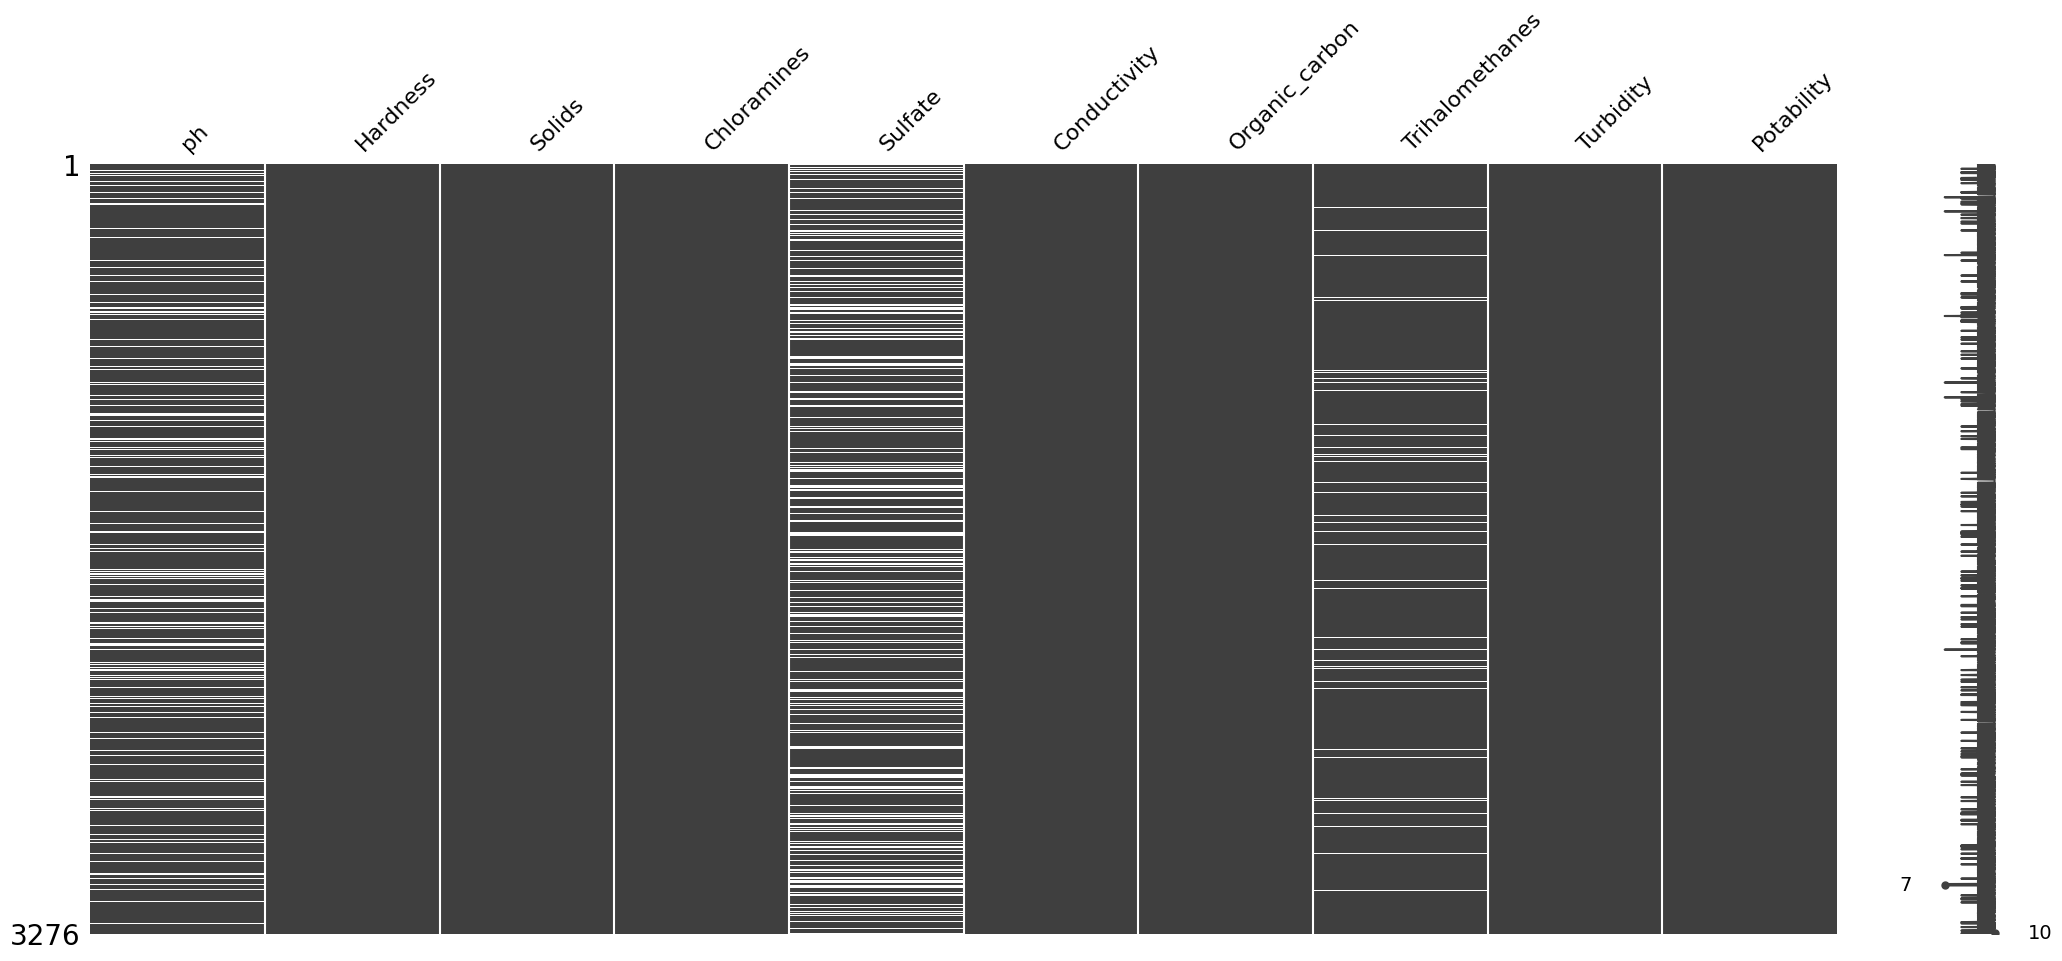

In [55]:
msno.matrix(water)

In [56]:
water.describe(include='all')

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## DATA EXPLORATION

### BOX PLOT

This graph allowed us to identify the data distribution and the presence of potential outliers. Its visual representation allows for quick identification of central tendencies, variability, and the presence of extreme values.

In [57]:
def boxplots(df,n=8):
    cols = list(df.columns)
    fig, axes = plt.subplots(5, 2, figsize=(15,8))
    plt.tight_layout(pad=3)
    for col, ax in enumerate(axes.flatten()):
        if df[cols[col]].dtypes=='float64':
            sns.boxplot(x=df[cols[col]], ax=ax)
        if col>n:
            break;
            
    axes[4, 1].axis('off')

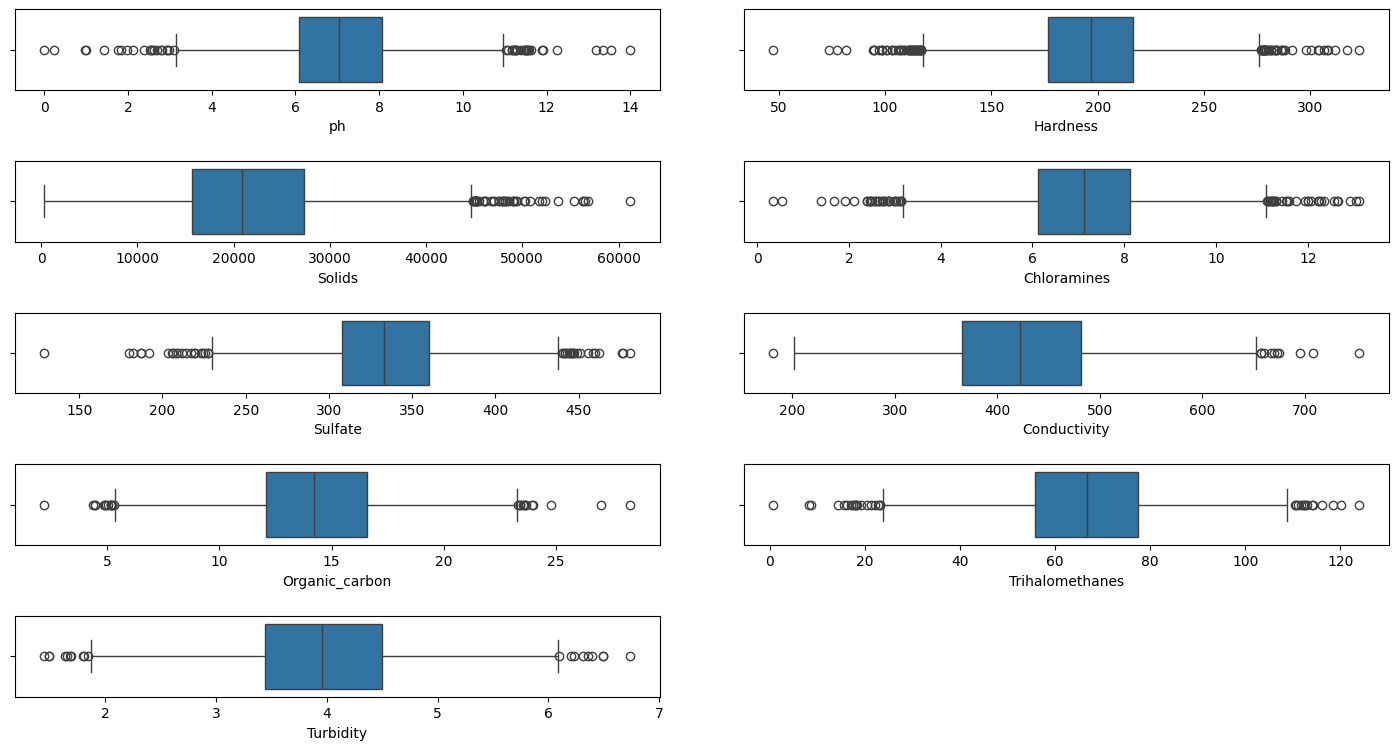

In [58]:
boxplots(water)

### HISTOGRAM

This graph provides a visual representation of the data distribution, illustrating the count of observations within each interval. It aids in identifying patterns, central tendencies for each features in the dataset.

In [59]:
def isto(df):
    cols = list(df.columns)
    fig, axes = plt.subplots(5, 2, figsize=(18,12))
    plt.tight_layout(pad=3)
    for col, ax in enumerate(axes.flatten()):
        if df[cols[col]].dtypes=='float64':
            sns.histplot(x=df[cols[col]], ax=ax)
        if df[cols[col]].dtypes=='int64':
            sns.countplot(x=df[cols[col]], ax=ax, palette='pastel')

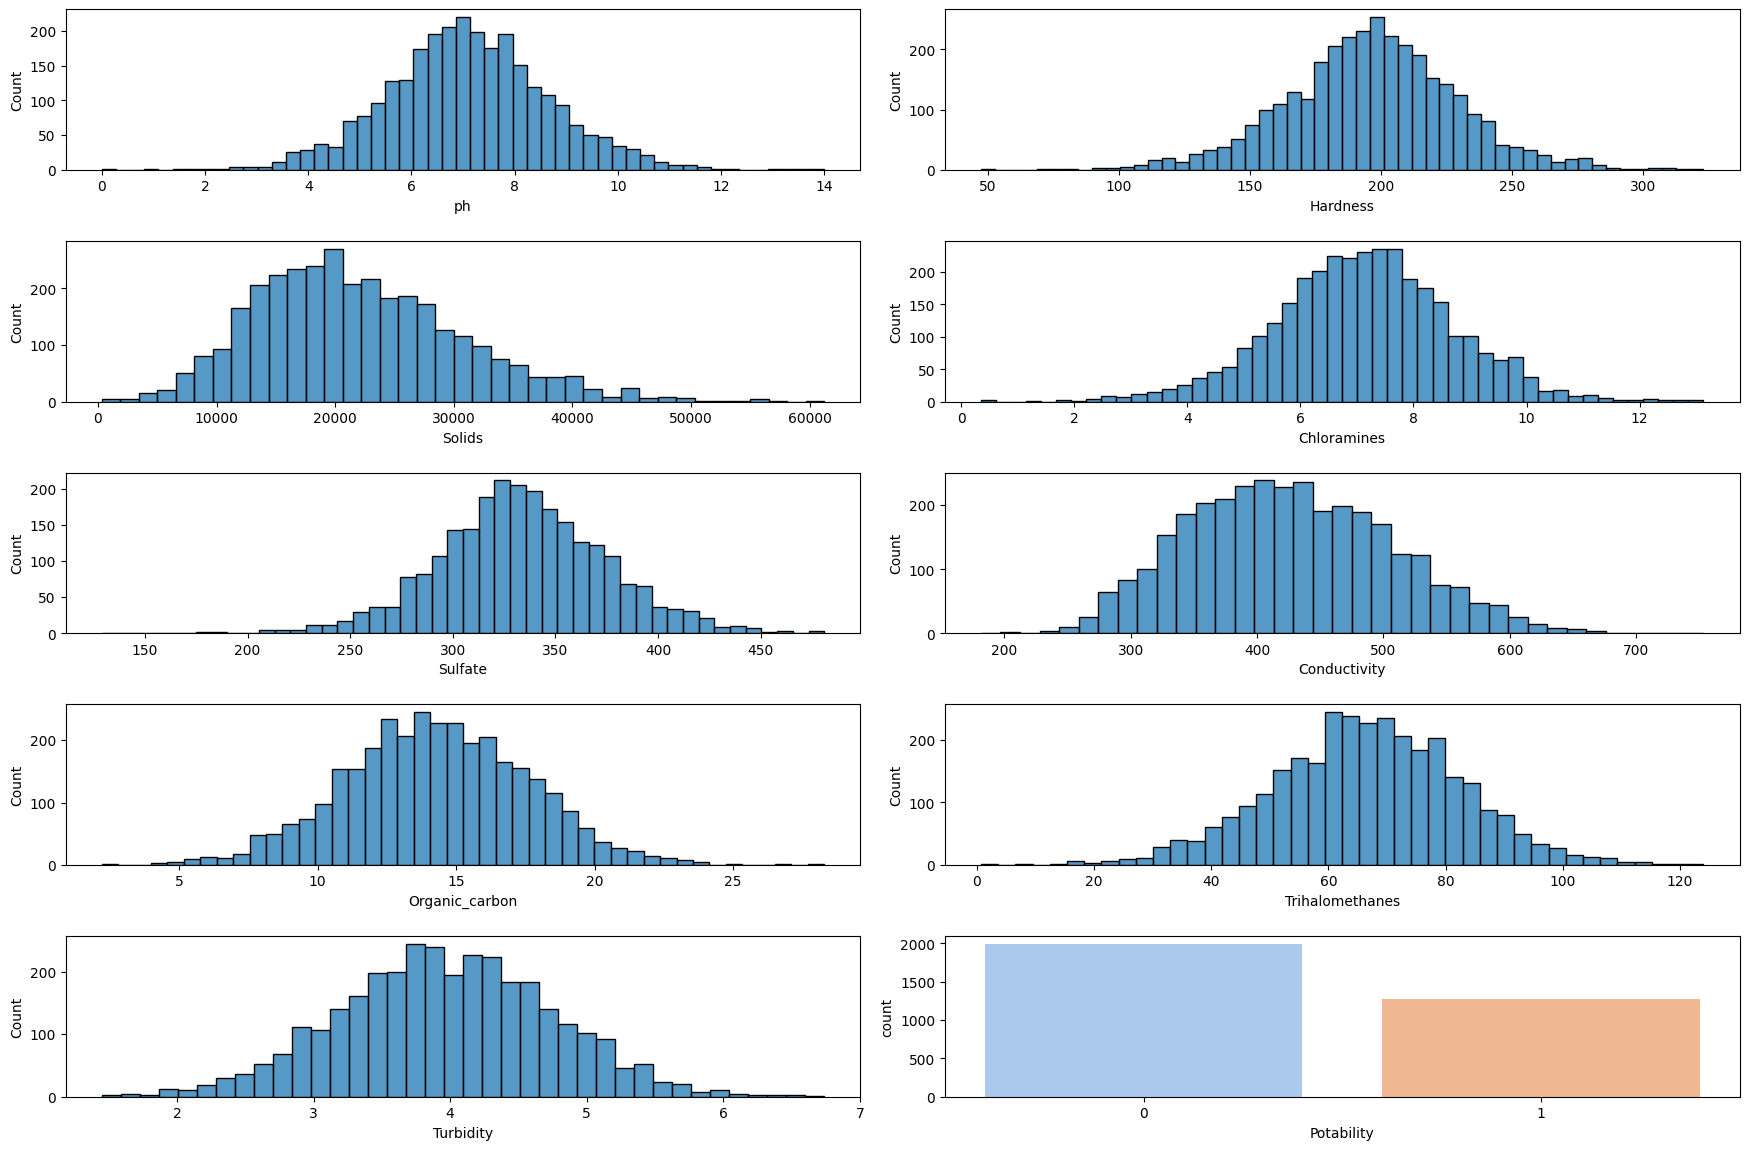

In [60]:
isto(water)

### SCATTER PLOT

This graph facilitates the analysis of relationships between variables in the dataset through scatter plots. This function colors the points based on a target variable(in our case 'Potability'). By looking at the scatter plots generated, we can determine whether the data are linearly separable. If the two classes present significantly overlap in the scatter plots, this suggests low linear separability. However, if the classes can be clearly separated by a single decision line, then the data are considered linearly separable.

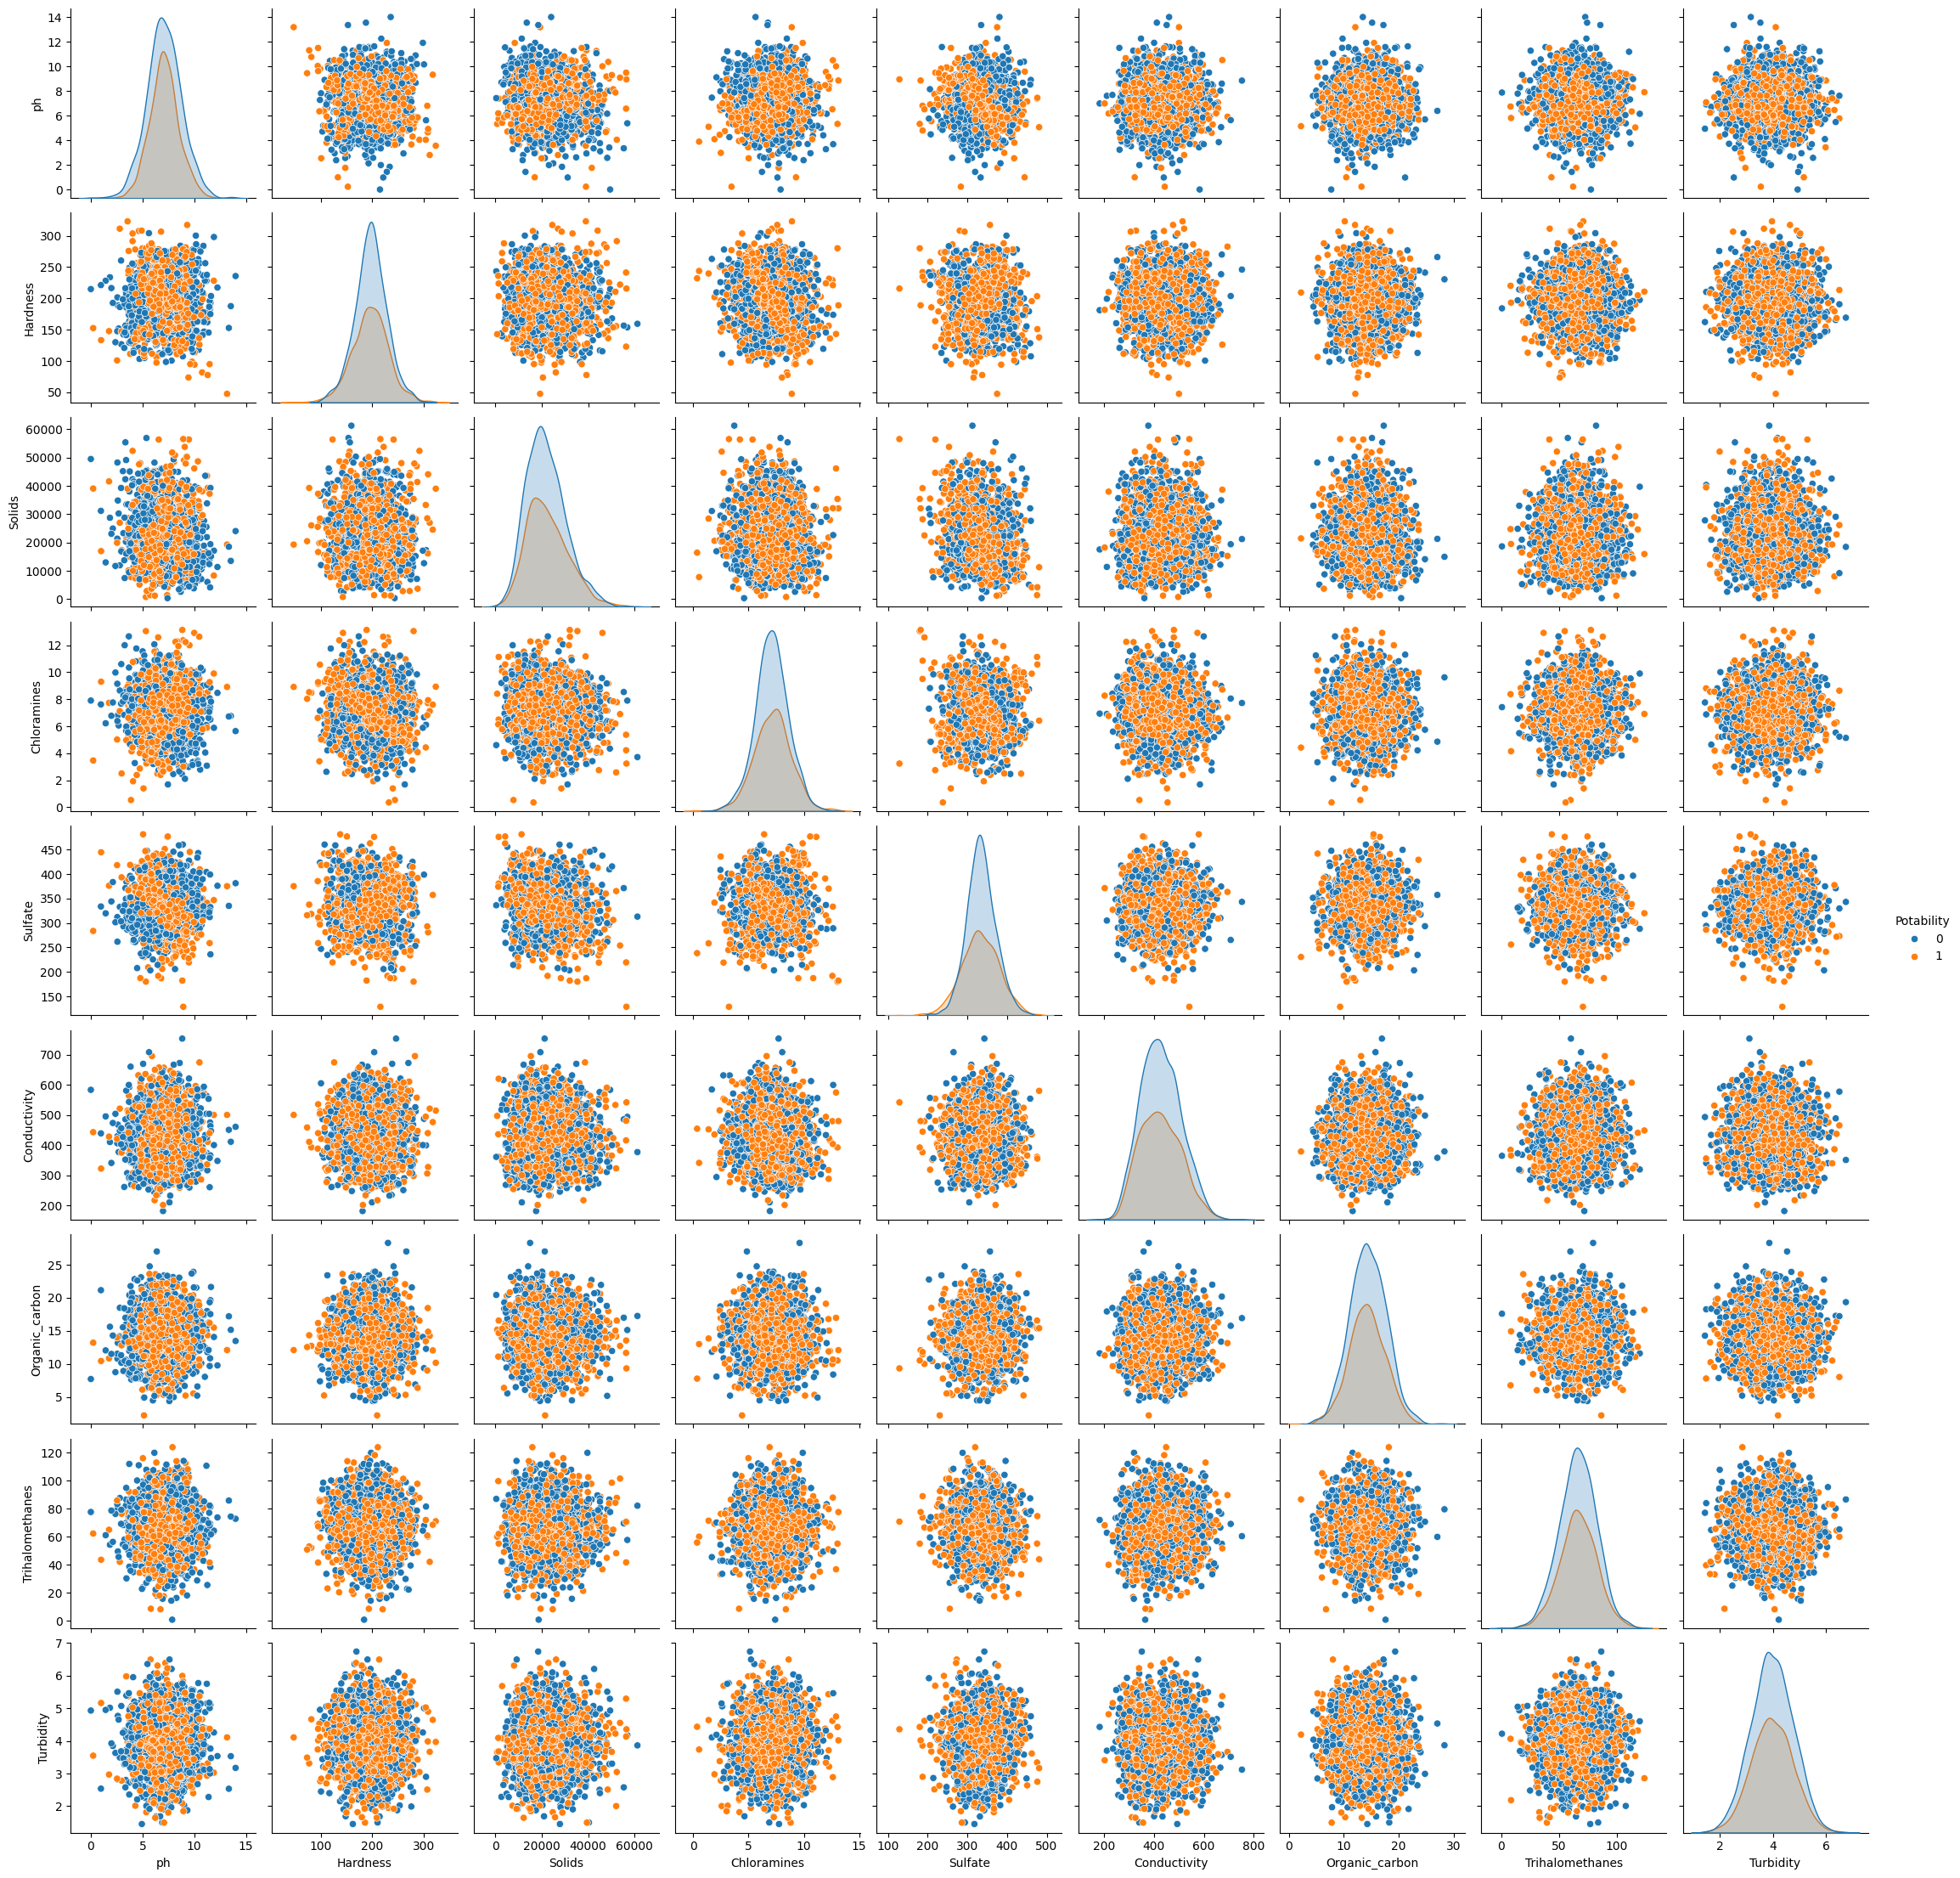

In [61]:
sns.pairplot(water, hue = 'Potability')

### CORRELATION MATRIX

This graph allow us to identify the correlation between the different features.

In [62]:
def plot_correlation_matrix(df):
    corr_matrix = df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()

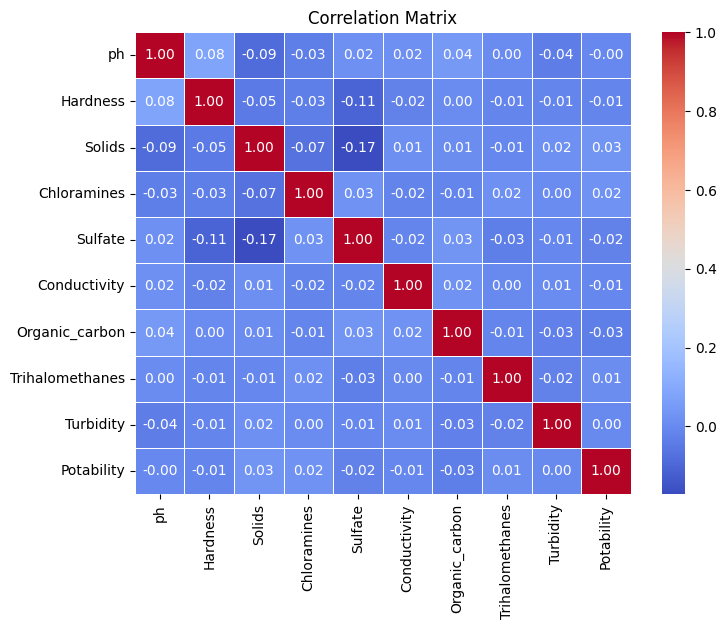

In [63]:
plot_correlation_matrix(water)

In [64]:
def correlation_matrices(df):
    df_potabile = df[df['Potability'] == 1]
    df_non_potabile = df[df['Potability'] == 0]
    
    df_potabile = df_potabile.drop(columns=['Potability'])
    df_non_potabile = df_non_potabile.drop(columns=['Potability'])
    
    corr_matrix_potabile = df_potabile.corr()
    corr_matrix_non_potabile = df_non_potabile.corr()
    
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(corr_matrix_potabile, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix - Potable Water')
    
    plt.subplot(1, 2, 2)
    sns.heatmap(corr_matrix_non_potabile, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix - Non-Potable Water')
    
    plt.tight_layout()
    plt.show()


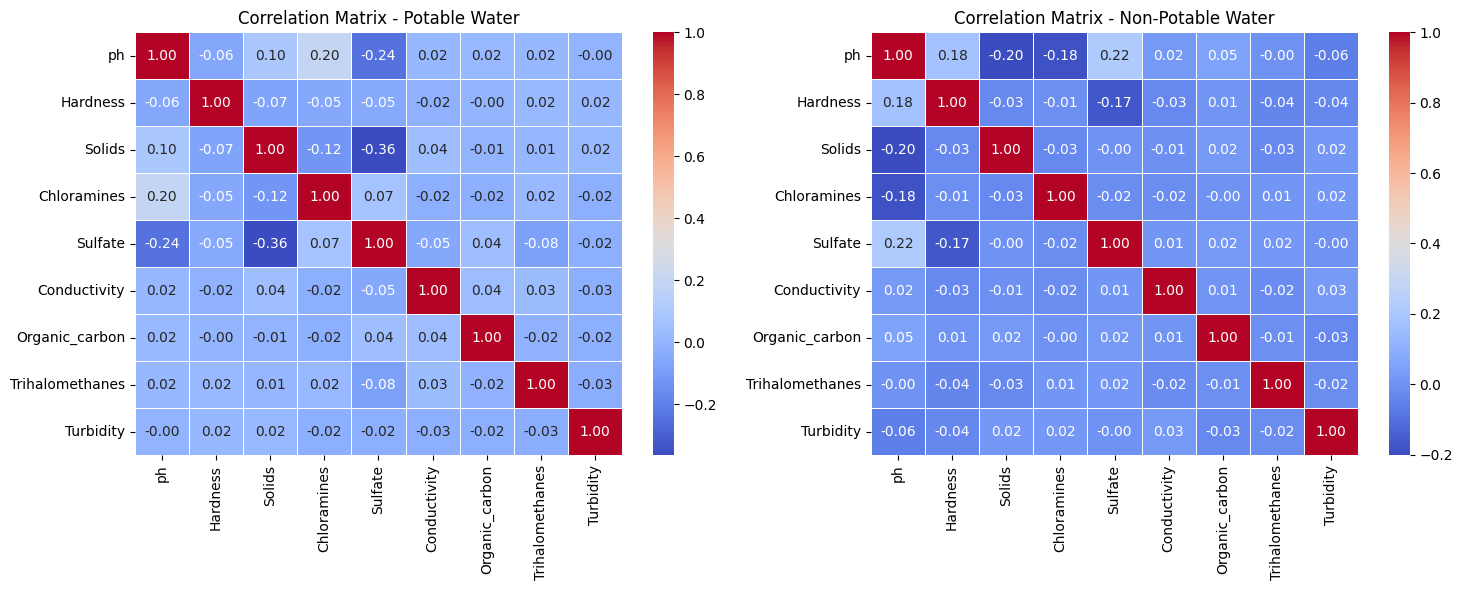

In [65]:
correlation_matrices(water)

## MODEL TRAINING and EVALUATION

### DATA SPLITTING

In [66]:
X = water.drop('Potability', axis=1)
y = water['Potability']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

### IMPUTER and RESAMPLING

In [68]:
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imp, y_train)

print("Train before SMOTE:", X_train_imp.shape, y_train.shape)
print("Train after SMOTE:",   X_train_res.shape,  y_train_res.shape)
print("Distribution of y_train before:", y_train.value_counts())
print("Distribution of y_train after:",  pd.Series(y_train_res).value_counts())

Train before SMOTE: (2620, 9) (2620,)
Train after SMOTE: (3172, 9) (3172,)
Distribution of y_train before: Potability
0    1586
1    1034
Name: count, dtype: int64
Distribution of y_train after: Potability
0    1586
1    1586
Name: count, dtype: int64


In [69]:
X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)
X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns)

### SETTING THE HYPERPARAMETERS

HYPERPARAMETERS for GRIDSEARCH

In [70]:
param_grid_knn = {
    'classifier__n_neighbors':  [3,5,7,9,11]
}


param_grid_perceptron = {
    'classifier__penalty': ['l2', 'l1'], 
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],   
    'classifier__max_iter': [100, 200, 500, 1000], 
    'classifier__eta0': [0.001, 0.01, 0.1]  
}

param_grid_logisticregression = {
    'classifier__C': [0.0001,0.001,0.01,0.1,1,10,100,1000],
    'classifier__penalty': ['l1', 'l2']
}


param_grid_randomforest = {
    'classifier__n_estimators': [50, 100, 150, 200],
    'classifier__max_depth': [10, 20, 30,100],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}


param_grid_XGB = [
    {
        'classifier__n_estimators' : [50, 100, 150, 200],
        'classifier__learning_rate' : [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth' : [3,5,7,9],
        'classifier__gamma': [0, 0.1, 0.2, 0.3, 0.4]
    }]


HYPERPARAMETERS for RANDOMIZEDSEARCH

In [71]:
param_random_knn = {
    'classifier__n_neighbors': np.arange(3, 16, 2)
}

param_random_perceptron = {
    'classifier__penalty': ['l2', 'l1'], 
    'classifier__alpha': loguniform(0.001, 100),   
    'classifier__max_iter': np.arange(100,1000,100), 
    'classifier__eta0': loguniform(0.001, 100) 
}

param_random_logisticregression = {
    'classifier__C': loguniform(0.001, 100),
    'classifier__penalty': ['l1', 'l2']
}


param_random_randomforest = {
    'classifier__n_estimators': np.arange(50, 251, 50),
    'classifier__max_depth': np.arange(10, 110, 10),
    'classifier__min_samples_split': np.arange(2, 11, 1),
    'classifier__min_samples_leaf': np.arange(1, 5, 1)
}


param_random_XGB = [
    {
        'classifier__n_estimators' : [50, 100, 150, 200],
        'classifier__learning_rate' : loguniform(0.001, 100),
        'classifier__max_depth' : [3,5,7,9],
        'classifier__gamma': uniform(0,1)
    }]

### IMPORTANT FUNCTIONS 

OPTIMIZATION FUNCTION: I create this function that automatizes the optimization of machine learning models by choosing between GridSearchCV and RandomizedSearchCV to find the optimal hyperparameter configuration. It returns the best model with its F1-score and predictions on the test set.

In [72]:
def optimization(X_train,y_train,pipeline,param_grid, param_random, title):

    grid_search = GridSearchCV(pipeline, param_grid, n_jobs=-1)

    grid_search.fit(X_train, y_train)

    y_grid = grid_search.predict(X_test)
    f1_grid = f1_score(y_test, y_grid, average='weighted')


    random_search = RandomizedSearchCV(pipeline,
                  param_random,
                  scoring='f1',
                  n_iter=50,
                  cv=5,
                  n_jobs=-1,
                  random_state=42)

    random_search.fit(X_train, y_train)

    y_random = random_search.predict(X_test)
    f1_random = f1_score(y_test, y_random, average='weighted')

    print('f1 grid:', f1_grid)
    print('f1 random:', f1_random )

    best_model = None
    y_best= None
    f1_best= None
    if f1_grid > f1_random:
        best_model = grid_search
        f1_best = f1_grid
        y_best = y_grid
        print("We use grid search for",title)
        print("F1-score:", f1_grid)
    else:
        best_model = random_search
        f1_best = f1_random
        y_best = y_random
        print("We use random search for",title)
        print("F1-score:", f1_random)

    print(best_model.best_estimator_)
    
    return best_model, f1_best, y_best


def performance_scores(label, y_test, y_pred):
    scores = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }

    df = pd.DataFrame(scores, index=[label])
    return df

In [73]:
def optimization(X_train, y_train, X_test, y_test,
                 pipeline, param_grid, param_random, title):

    grid_search = GridSearchCV(pipeline, param_grid, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    y_grid = grid_search.predict(X_test)
    f1_grid = f1_score(y_test, y_grid, average='weighted')

    random_search = RandomizedSearchCV(
        pipeline,
        param_random,
        scoring='f1',
        n_iter=50,
        cv=5,
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_train, y_train)

    y_random = random_search.predict(X_test)
    f1_random = f1_score(y_test, y_random, average='weighted')

    print('f1 grid:', f1_grid)
    print('f1 random:', f1_random)

    best_model = None
    y_best = None
    f1_best = None

    if f1_grid > f1_random:
        best_model = grid_search.best_estimator_
        f1_best = f1_grid
        y_best = y_grid
        print("We use grid search for", title)
        print("F1-score:", f1_grid)
    else:
        best_model = random_search.best_estimator_
        f1_best = f1_random
        y_best = y_random
        print("We use random search for", title)
        print("F1-score:", f1_random)

    print(best_model)
    return best_model, f1_best, y_best


LEARNING CURVE: Shows how model performance (f1) changes as the size of the training set changes.

VALIDATION CURVE: Shows how model performance (f1) changes as a function of a specific hyperparameter.

In [74]:
def learning_curve_function(grid, X, y):
    train_sizes, train_scores, test_scores = learning_curve(grid, X=X, y=y, train_sizes=[0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], cv=5, n_jobs=-1, scoring='f1', shuffle=False)
    return train_sizes, train_scores, test_scores

def validation_curve_function (grid, X, y, range, param_name):
    train_scores, test_scores = validation_curve(
    grid,
    X=X, 
    y=y, 
    param_range = range, 
    param_name=param_name,
    cv=5, 
    n_jobs=-1, 
    scoring='f1'
)
    return train_scores, test_scores

def plot_learning(ax, train_sizes, train_scores, test_scores):
    ax.plot(train_sizes, np.mean(train_scores, axis=1),
                color='blue', marker='+', markersize=5, label='Training f1')
    ax.fill_between(train_sizes,
                            np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                            np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                            alpha=0.15, color='blue')
    ax.plot(train_sizes, np.mean(test_scores, axis=1),
                    color='green', linestyle='--', marker='d', markersize=5, label='Validation f1')
    ax.fill_between(train_sizes,
                            np.mean(test_scores, axis=1) + np.std(test_scores, axis=1),
                            np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
                            alpha=0.15, color='green')
    ax.grid(True)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('F1-score')
    ax.legend(loc='lower right')
    ax.set_ylim([0, 1.05])
    ax.set_title('Training Curve')

def plot_validation(ax, parameter, train_scores, test_scores, x_label, x_scale, x_lim):
    ax.plot(parameter, np.mean(train_scores, axis=1),
                color='blue', marker='+', markersize=5, label='Training f1')
    ax.fill_between(parameter,
                            np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                            np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                            alpha=0.15, color='blue')
    ax.plot(parameter, np.mean(test_scores, axis=1),
                    color='green', linestyle='--', marker='d', markersize=5, label='Validation f1')
    ax.fill_between(parameter,
                            np.mean(test_scores, axis=1) + np.std(test_scores, axis=1),
                            np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
                            alpha=0.15, color='green')
    ax.grid(True)
    ax.set_xlabel(x_label)
    ax.set_ylabel('F1-score')
    ax.legend(loc='lower right')
    ax.set_ylim([0.0, 1.1])
    ax.set_xscale(x_scale)
    ax.set_xlim(x_lim)
    ax.set_title('Validation Curve')

### K-NEAREST NEIGHBORS (KNN)

In [75]:
pipeline_knn = Pipeline([
    ('scaler', RobustScaler()), 
    ('classifier', KNeighborsClassifier())
])

In [76]:
warnings.filterwarnings("ignore")
best_model_knn, f1_best_knn, y_best_knn = optimization(X_train_res, y_train_res, X_test_imp, y_test,
                                                      pipeline_knn, param_grid_knn, param_random_knn,'knn')

f1 grid: 0.615947610277018
f1 random: 0.615947610277018
We use random search for knn
F1-score: 0.615947610277018
Pipeline(steps=[('scaler', RobustScaler()),
                ('classifier', KNeighborsClassifier(n_neighbors=np.int64(3)))])


In [77]:
results_knn= performance_scores('KNN',y_test, y_best_knn)
results_knn

,Accuracy,Precision,Recall,F1-Score
KNN,0.609756,0.633524,0.609756,0.615948


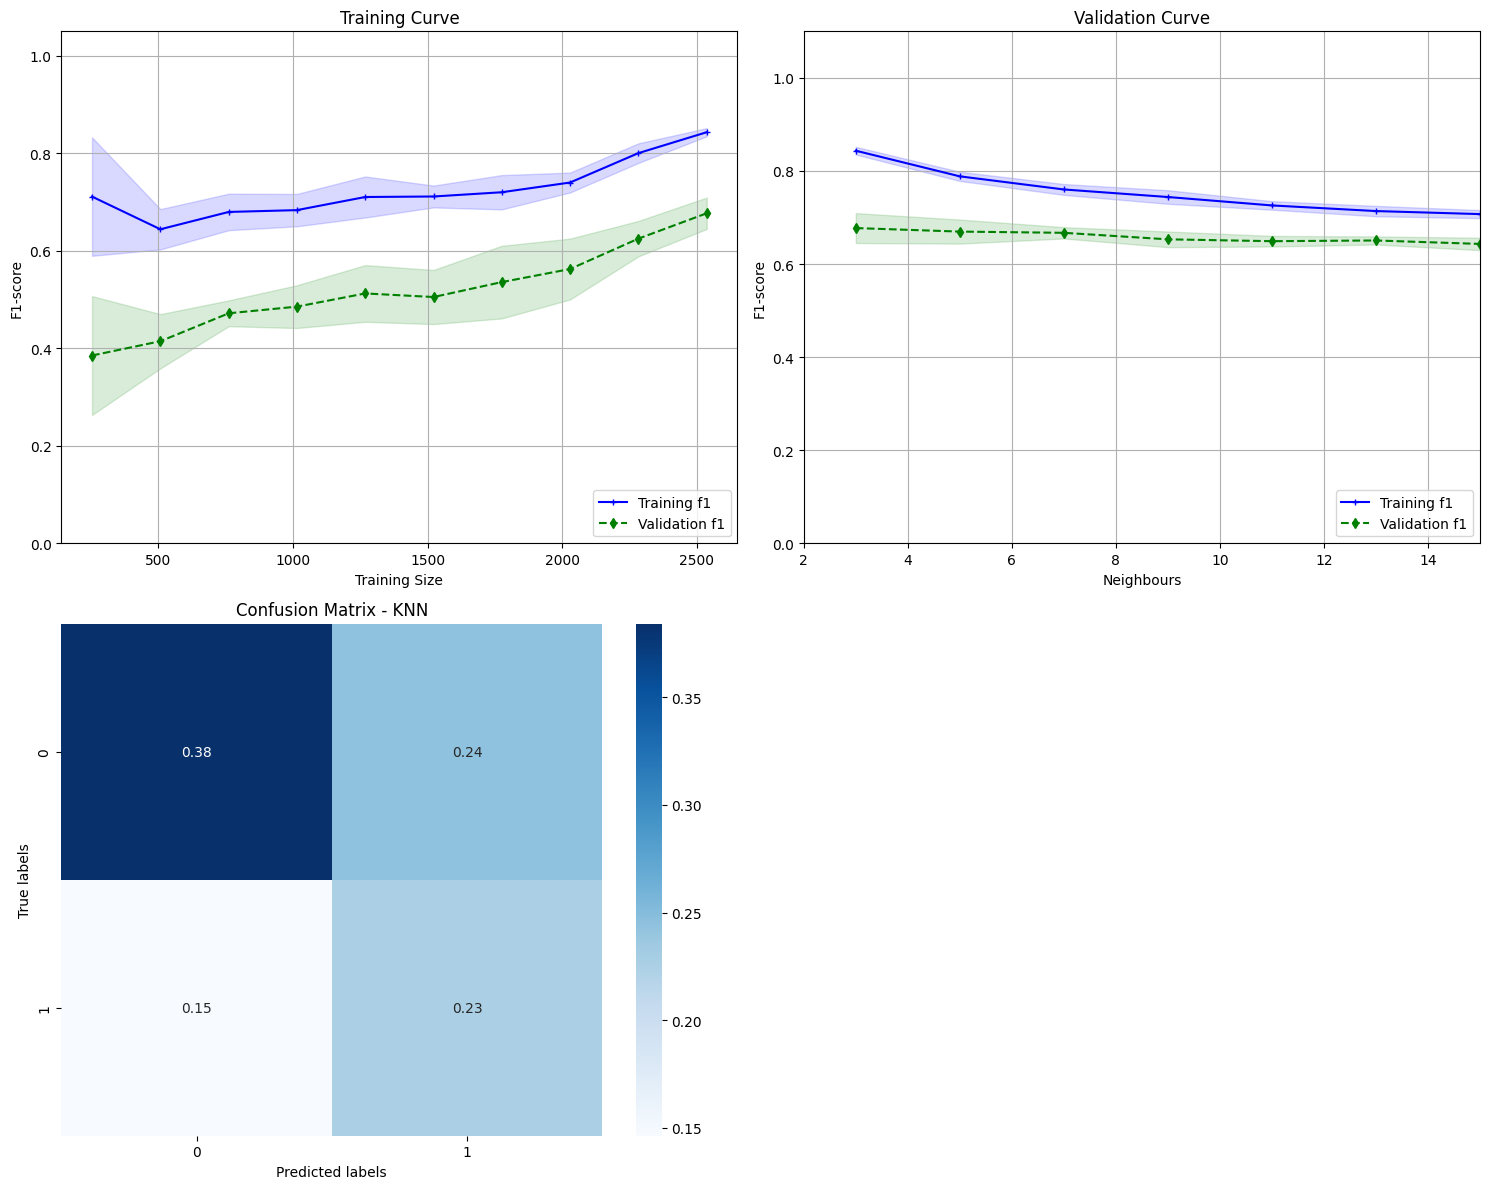

In [78]:
train_sizes_knn_learning, train_scores_knn_learning, test_scores_knn_learning = learning_curve_function(best_model_knn,X_train_res, y_train_res)

param_neighbours = [3,5,7,9,11,13,15]
train_scores_knn_validation, test_scores_knn_validation = validation_curve_function(best_model_knn, X_train_res, y_train_res, param_neighbours, 'classifier__n_neighbors')


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))


plot_learning(axes[0, 0], train_sizes_knn_learning, train_scores_knn_learning, test_scores_knn_learning)
plot_validation(axes[0, 1], param_neighbours, train_scores_knn_validation, test_scores_knn_validation,'Neighbours','linear',[2,15])


cm_knn = confusion_matrix(y_test, y_best_knn)
sns.heatmap(cm_knn/np.sum(cm_knn), annot = True, fmt='.2f', cmap = 'Blues', ax=axes[1,0])  
axes[1, 0].set_title('Confusion Matrix - KNN')
axes[1, 0].set_xlabel('Predicted labels')
axes[1, 0].set_ylabel('True labels')

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### PERCEPTRON

<i>The use of the Perceptron despite the fact that the classes are not linearly separable is motivated by the desire to explore and understand the limitations of the learning model and provide a starting point for the analysis of more complex solutions suitable for nonlinear problems.</i>


In [79]:
pipeline_perceptron = Pipeline([
    ('scaler', RobustScaler()), 
    ('classifier', Perceptron()) 
])


In [80]:
best_model_peceptron, f1_best_perceptron, y_best_perceptron = optimization(X_train_res, y_train_res, X_test_imp, y_test,
                                                                            pipeline_perceptron, param_grid_perceptron, param_random_perceptron,'perceptron')

f1 grid: 0.5128339729337011
f1 random: 0.20168021680216805
We use grid search for perceptron
F1-score: 0.5128339729337011
Pipeline(steps=[('scaler', RobustScaler()),
                ('classifier',
                 Perceptron(alpha=0.1, eta0=0.1, max_iter=100, penalty='l2'))])


In [81]:
results_perceptron=performance_scores('PERCEPTRON',y_test,y_best_perceptron)
results_perceptron

,Accuracy,Precision,Recall,F1-Score
PERCEPTRON,0.504573,0.536973,0.504573,0.512834


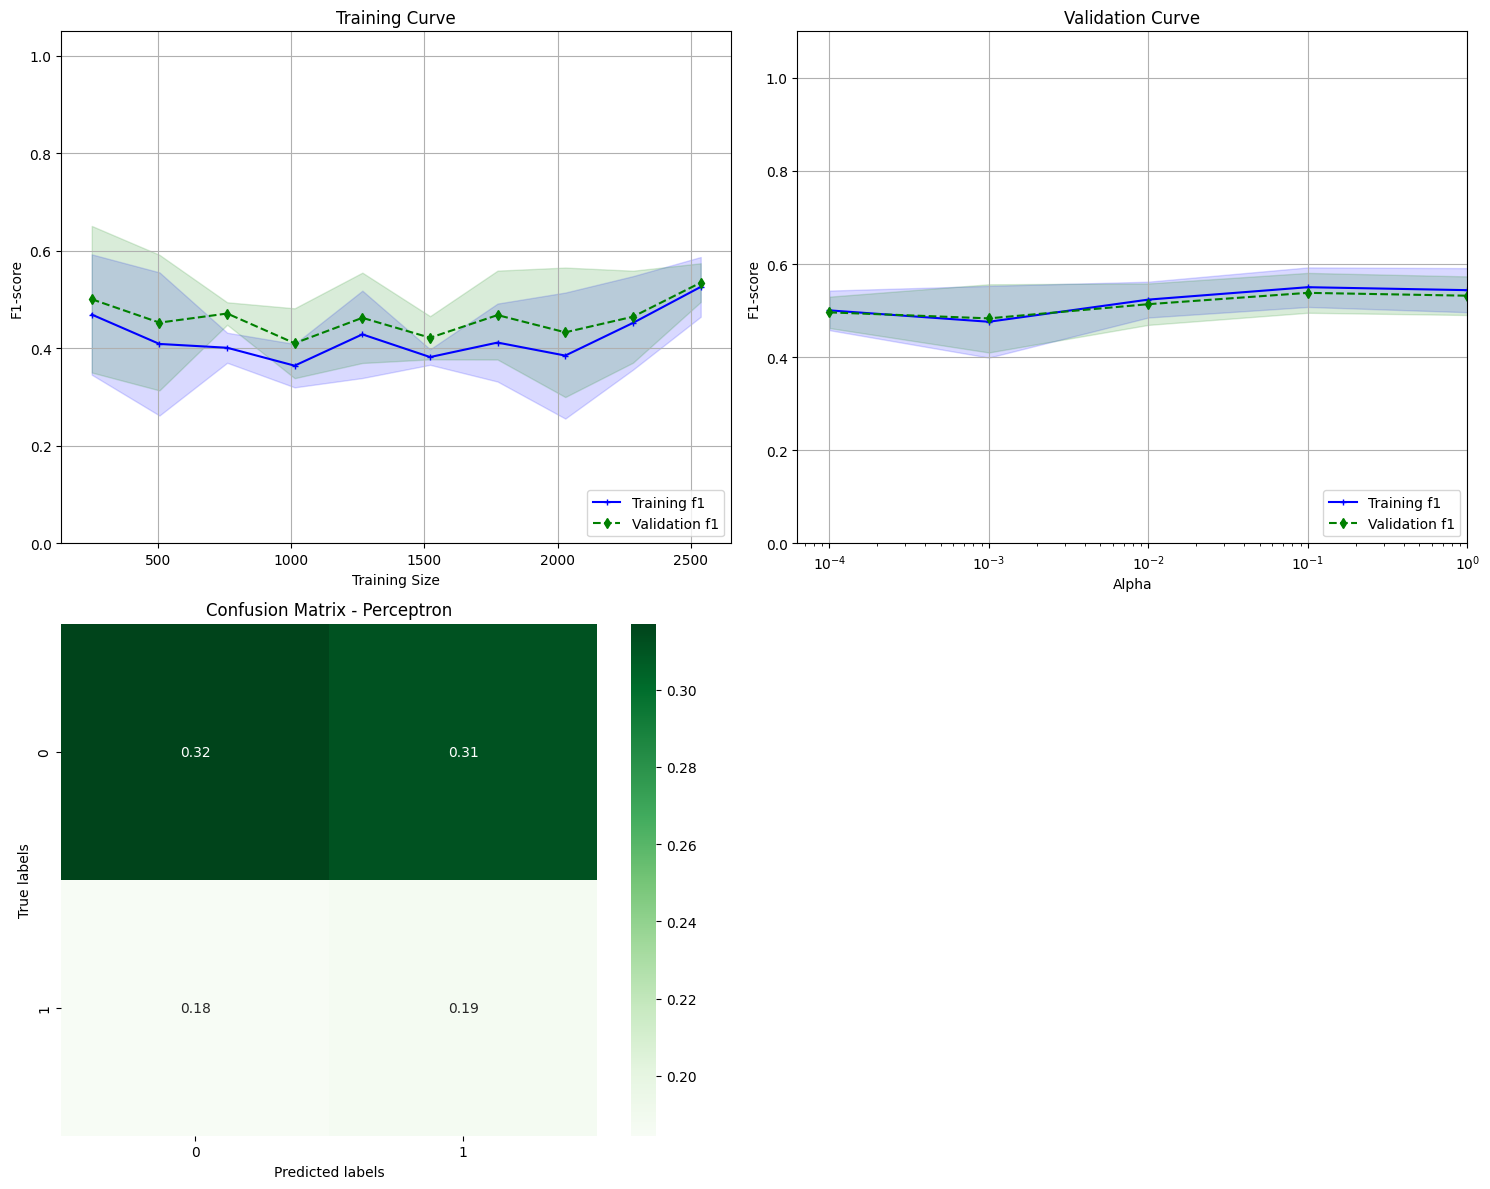

In [82]:
train_sizes_percep_learning, train_scores_percep_learning, test_scores_percep_learning = learning_curve_function(best_model_peceptron,X_train_res, y_train_res)

param_alpha = [0.0001, 0.001, 0.01, 0.1,1]
train_scores_percep_validation, test_scores_percep_validation = validation_curve_function(best_model_peceptron,X_train_res, y_train_res, param_alpha, 'classifier__alpha')


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))


plot_learning(axes[0, 0], train_sizes_percep_learning, train_scores_percep_learning, test_scores_percep_learning)
plot_validation(axes[0, 1], param_alpha, train_scores_percep_validation, test_scores_percep_validation, 'Alpha','log',[0,1])

cm_percep = confusion_matrix(y_test, y_best_perceptron)
sns.heatmap(cm_percep/np.sum(cm_percep), annot = True, fmt=  '.2f', cmap = 'Greens', ax=axes[1,0])  
axes[1, 0].set_title('Confusion Matrix - Perceptron')
axes[1, 0].set_xlabel('Predicted labels')
axes[1, 0].set_ylabel('True labels')

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### LOGISTIC REGRESSION

In [83]:
pipeline_logisticregression = Pipeline([
    ('scaler', RobustScaler()), 
    ('classifier', LogisticRegression()) 
])

In [84]:
best_model_logistic, f1_best_logistic,y_best_logistic = optimization(X_train_res, y_train_res, X_test_imp, y_test,
                                                                    pipeline_logisticregression, param_grid_logisticregression, param_random_logisticregression,'logistic regression')

f1 grid: 0.5171265002955614
f1 random: 0.5187253480729229
We use random search for logistic regression
F1-score: 0.5187253480729229
Pipeline(steps=[('scaler', RobustScaler()),
                ('classifier',
                 LogisticRegression(C=np.float64(3.4702669886504163)))])


In [85]:
results_lr=performance_scores('LOGISTIC REGRESSION', y_test, y_best_logistic)
results_lr

,Accuracy,Precision,Recall,F1-Score
LOGISTIC REGRESSION,0.510671,0.539122,0.510671,0.518725


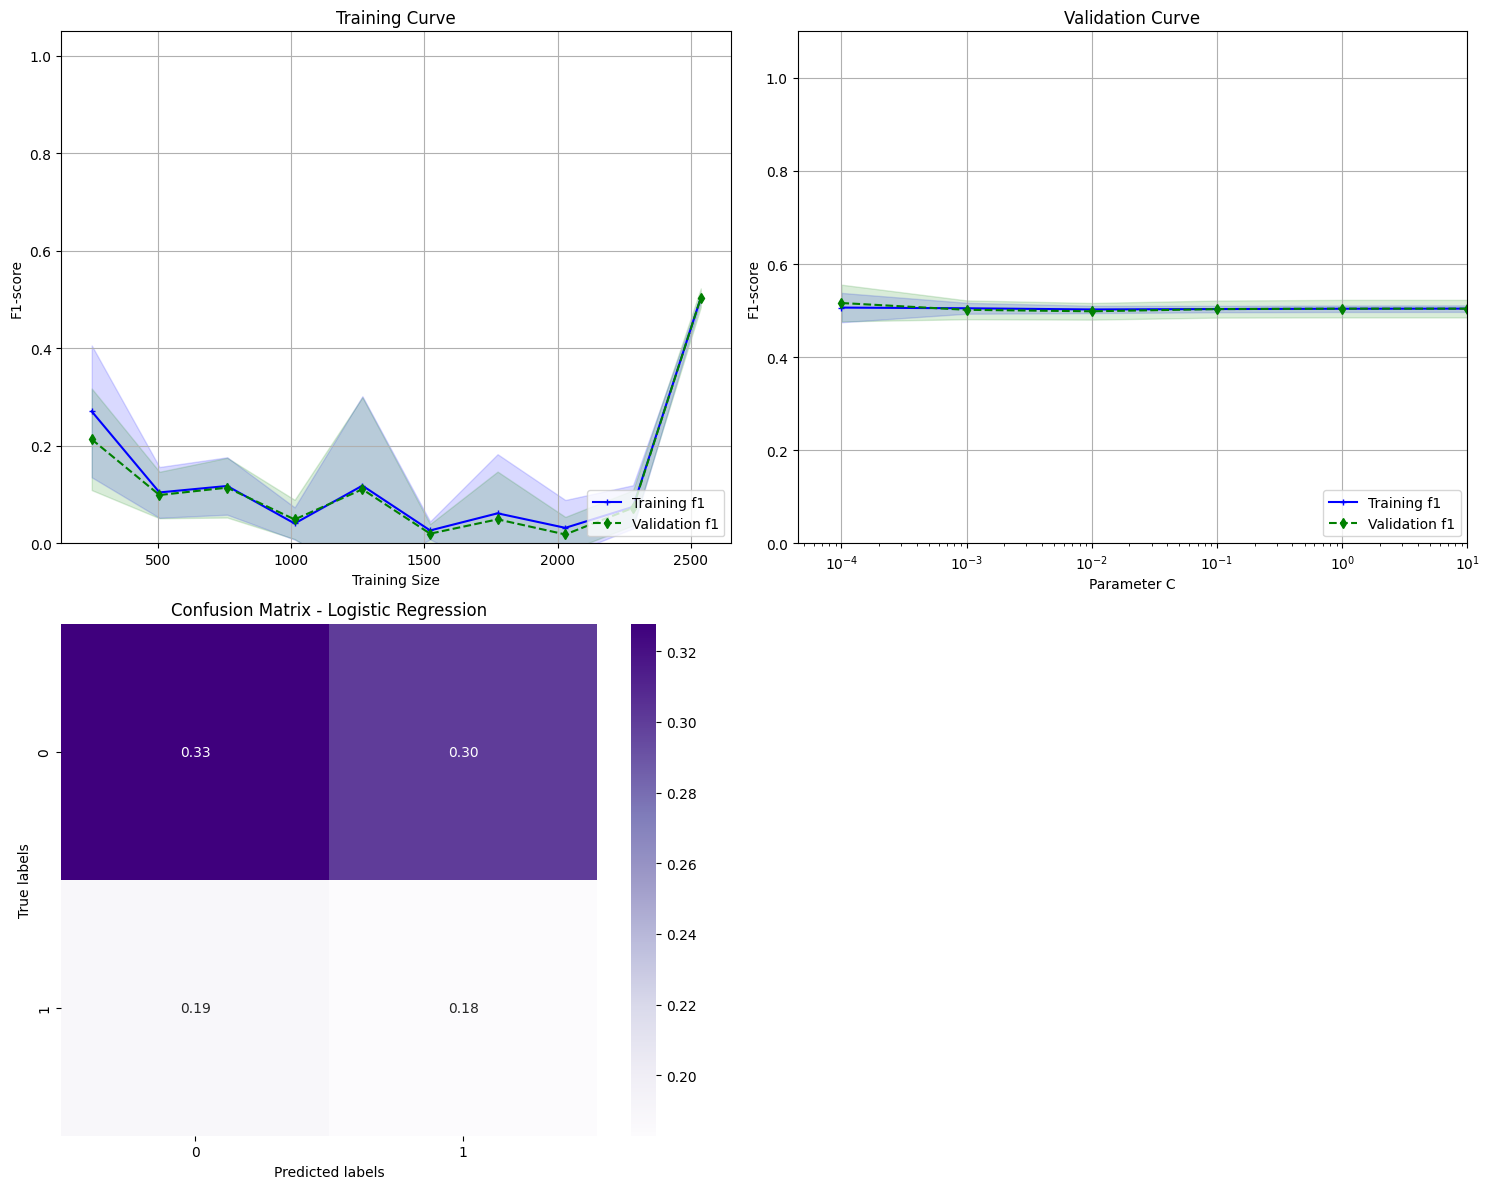

In [86]:
train_sizes_lr_learning, train_scores_lr_learning, test_scores_lr_learning = learning_curve_function(best_model_logistic,X_train_res, y_train_res)

param_C = [0.0001,0.001,0.01,0.1,1,10,100,1000]
train_scores_lr_validation, test_scores_lr_validation = validation_curve_function(best_model_logistic,X_train_res, y_train_res, param_C, 'classifier__C')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))


plot_learning(axes[0, 0], train_sizes_lr_learning, train_scores_lr_learning, test_scores_lr_learning)
plot_validation(axes[0, 1], param_C, train_scores_lr_validation, test_scores_lr_validation,'Parameter C','log',[0,10])


cm_lr = confusion_matrix(y_test, y_best_logistic)
sns.heatmap(cm_lr/np.sum(cm_lr), annot = True, fmt=  '.2f', cmap = 'Purples', ax=axes[1,0]) 
axes[1, 0].set_title('Confusion Matrix - Logistic Regression')
axes[1, 0].set_xlabel('Predicted labels')
axes[1, 0].set_ylabel('True labels')

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### RANDOM FOREST (Ensemble Learning: BAGGING)

In [87]:
pipeline_randomforest = Pipeline([
    ('scaler', RobustScaler()), 
    ('classifier', RandomForestClassifier()) 
])

In [88]:
best_model_randomforest, f1_best_randomforest, y_best_randomforest = optimization(X_train_res, y_train_res, X_test_imp, y_test,
                                                                                pipeline_randomforest, param_grid_randomforest, param_random_randomforest,'random forest')

f1 grid: 0.6508871482261074
f1 random: 0.6521479016249223
We use random search for random forest
F1-score: 0.6521479016249223
Pipeline(steps=[('scaler', RobustScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=np.int64(40),
                                        min_samples_leaf=np.int64(1),
                                        min_samples_split=np.int64(4),
                                        n_estimators=np.int64(100)))])


In [89]:
results_rf = performance_scores('RANDOM FOREST',y_test, y_best_randomforest)
results_rf

,Accuracy,Precision,Recall,F1-Score
RANDOM FOREST,0.650915,0.653623,0.650915,0.652148


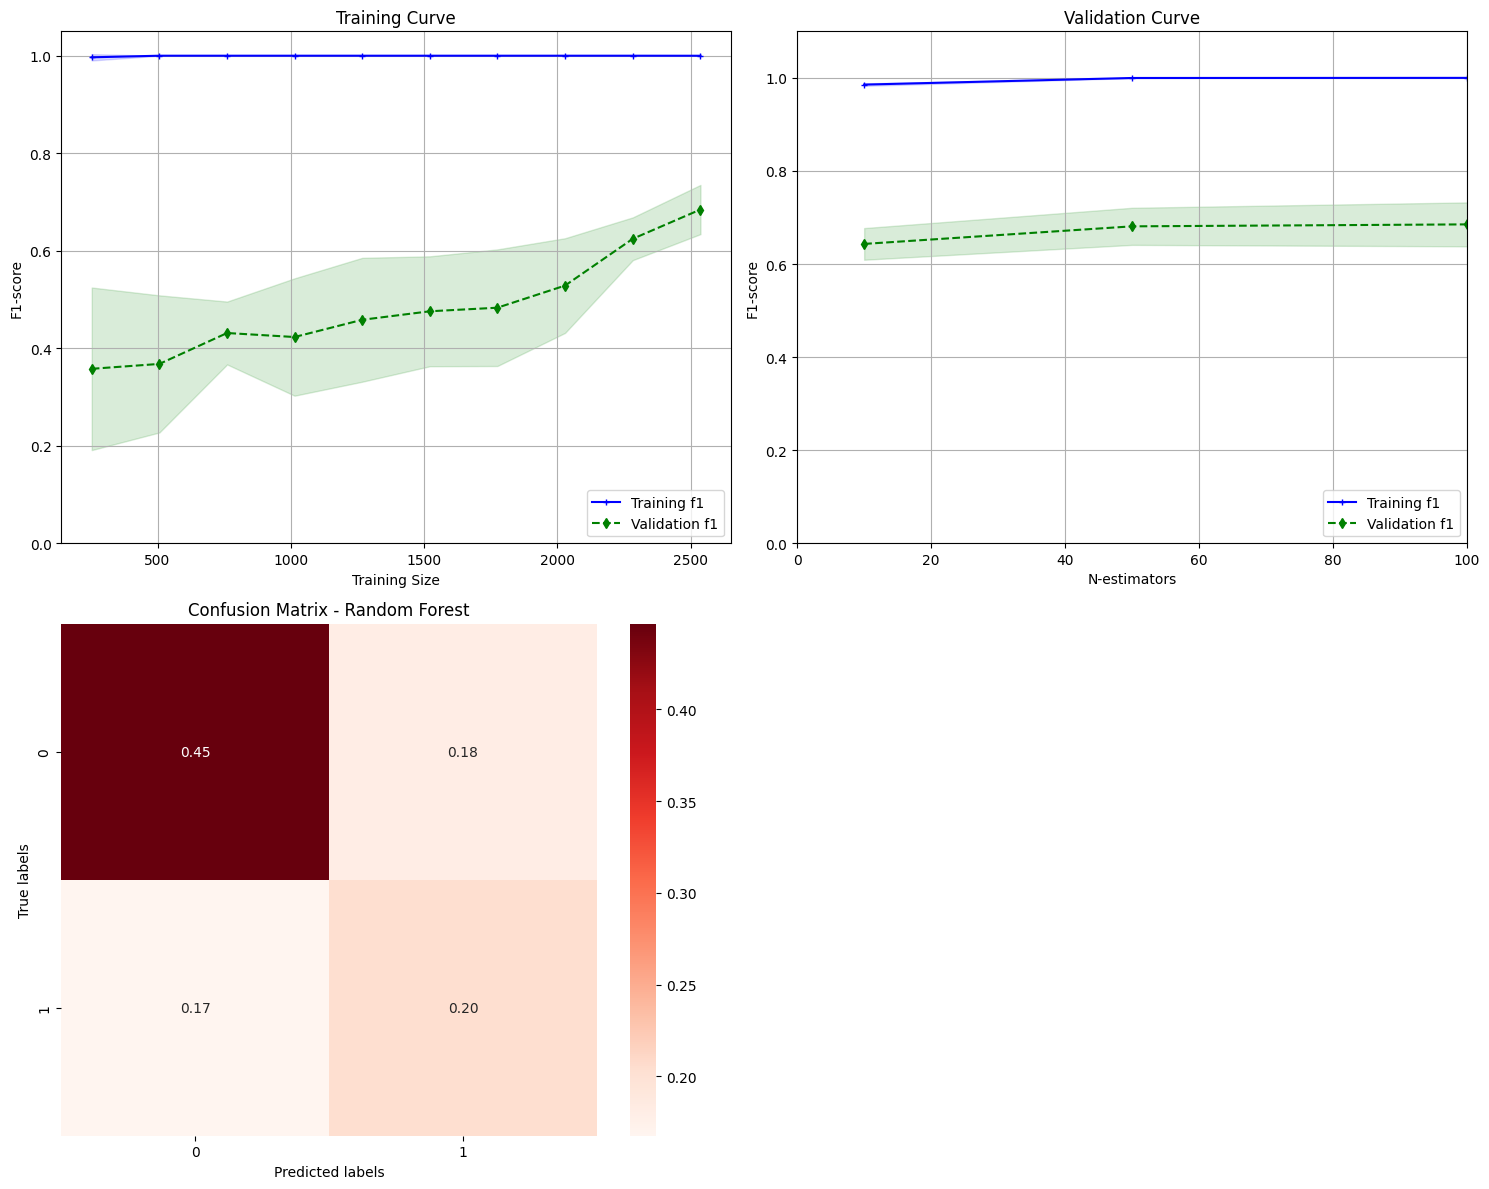

In [90]:
train_sizes_rf_learning, train_scores_rf_learning, test_scores_rf_learning = learning_curve_function(best_model_randomforest, X_train_res, y_train_res)

param_estimators = [10, 50, 100, 150, 200]
train_scores_rf_validation, test_scores_rf_validation = validation_curve_function(best_model_randomforest, X_train_res, y_train_res, param_estimators, 'classifier__n_estimators')


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))


plot_learning(axes[0, 0], train_sizes_rf_learning, train_scores_rf_learning, test_scores_rf_learning)
plot_validation(axes[0, 1], param_estimators, train_scores_rf_validation, test_scores_rf_validation, 'N-estimators','linear',[0,100])

cm_rf = confusion_matrix(y_test, y_best_randomforest)
sns.heatmap(cm_rf/np.sum(cm_rf), annot = True, fmt=  '.2f', cmap = 'Reds', ax=axes[1,0]) 
axes[1, 0].set_title('Confusion Matrix - Random Forest')
axes[1, 0].set_xlabel('Predicted labels')
axes[1, 0].set_ylabel('True labels')

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### eXtreme GRADIENT BOOSTING (XGB), (Ensemble Learning: BOOSTING)

In [91]:
pipeline_XGB = Pipeline([
    ('scaler', RobustScaler()), 
    ('classifier', XGBClassifier()) 
])

In [92]:
best_model_XGB, f1_best_XGB, y_best_XGB = optimization(X_train_res, y_train_res, X_test_imp, y_test,
                                                      pipeline_XGB, param_grid_XGB, param_random_XGB,'XGB')

f1 grid: 0.6376122907337137
f1 random: 0.6600743285359466
We use random search for XGB
F1-score: 0.6600743285359466
Pipeline(steps=[('scaler', RobustScaler()),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None,
                               gamma=np.float64(0.6232981268275579),
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=np.float64(0.04513257622008944),
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None

In [93]:
results_xgb = performance_scores('XGB',y_test,y_best_XGB)
results_xgb

,Accuracy,Precision,Recall,F1-Score
XGB,0.661585,0.65887,0.661585,0.660074


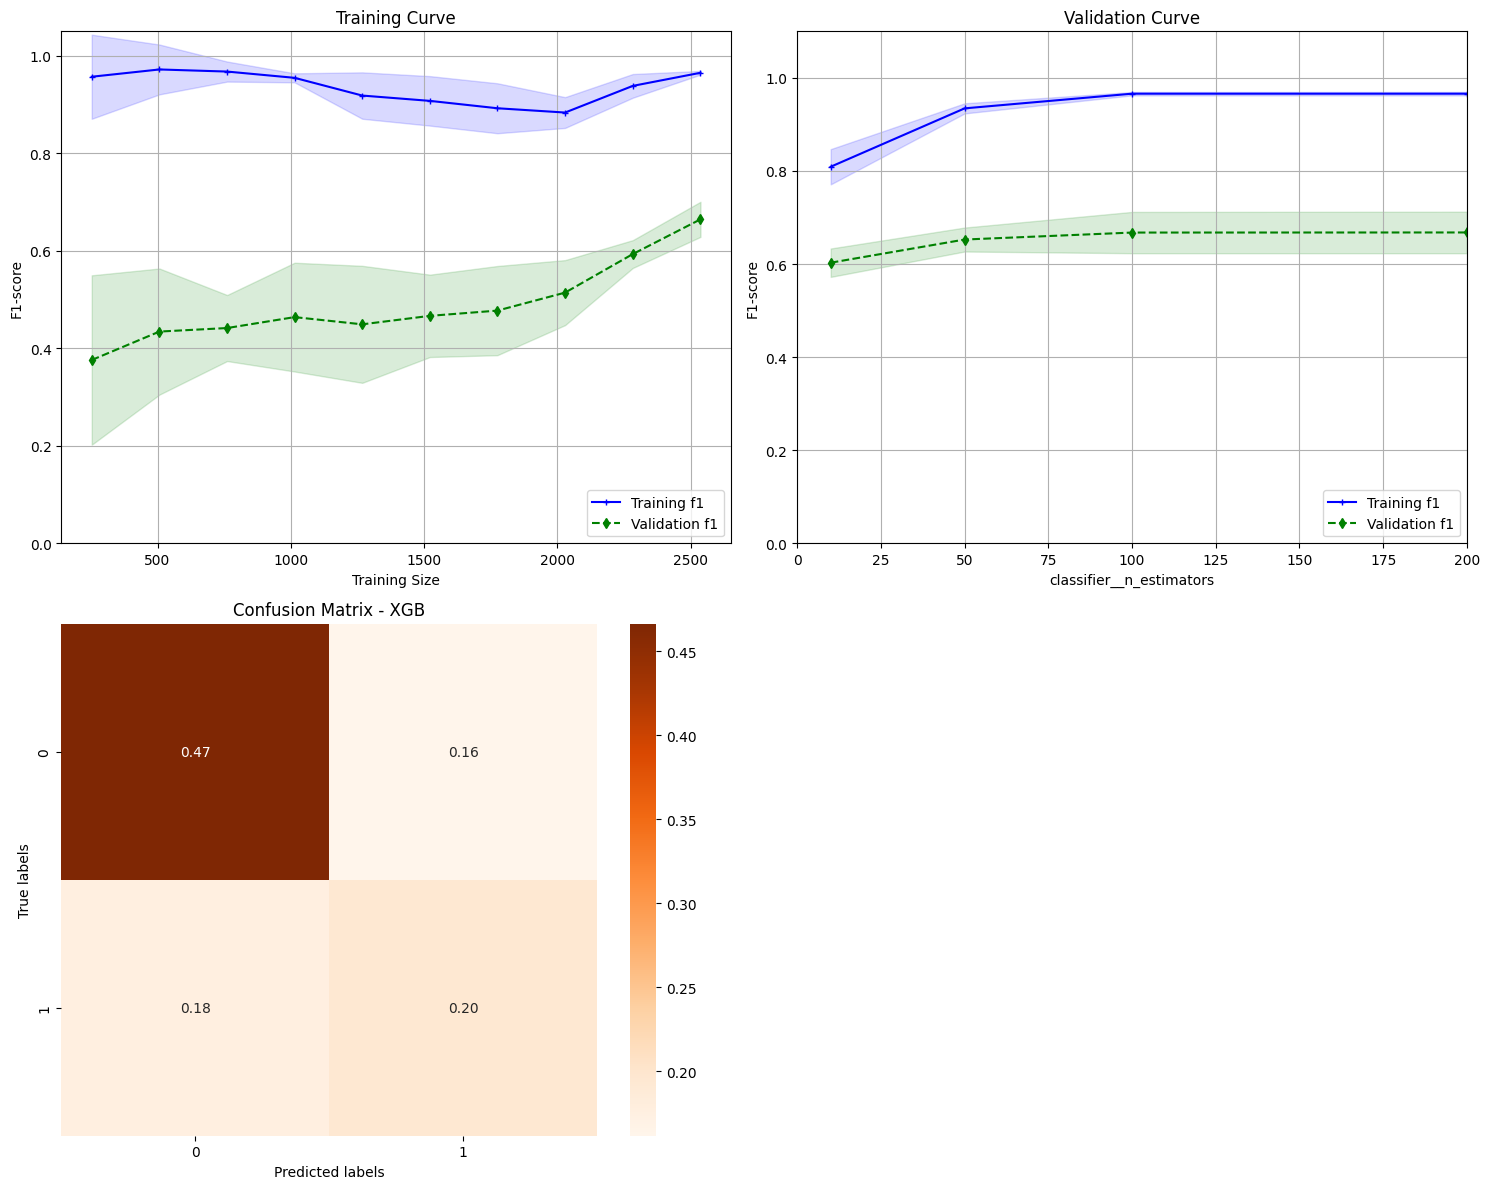

In [94]:
train_sizes_xgb_learning, train_scores_xgb_learning, test_scores_xgb_learning = learning_curve_function(best_model_XGB,X_train_res, y_train_res)

param_estimators = [10, 50, 100, 200]
train_scores_xgb_validation, test_scores_xgb_validation = validation_curve_function(best_model_XGB,X_train_res, y_train_res, param_estimators, 'classifier__n_estimators')


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))


plot_learning(axes[0, 0], train_sizes_xgb_learning, train_scores_xgb_learning, test_scores_xgb_learning,)
plot_validation(axes[0, 1], param_estimators, train_scores_xgb_validation, test_scores_xgb_validation,'classifier__n_estimators', 'linear',[0,200])

cm_xgb = confusion_matrix(y_test, y_best_XGB)
sns.heatmap(cm_xgb/np.sum(cm_xgb), annot = True, fmt=  '.2f', cmap = 'Oranges', ax=axes[1,0]) 
axes[1, 0].set_title('Confusion Matrix - XGB')
axes[1, 0].set_xlabel('Predicted labels')
axes[1, 0].set_ylabel('True labels')

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### VOTING CLASSIFIER

In [100]:
#ENSEMBLE LEARNING (Voting)
voting_model = VotingClassifier(estimators=[
    ('knn', best_model_knn),
    ('percep', best_model_peceptron),
    ('lr', best_model_logistic),
    ('rf', best_model_randomforest),
    ('xgb', best_model_XGB)
], voting='hard', n_jobs=-1)  


voting_model.fit(X_train_res, y_train_res)

y_pred_voting = voting_model.predict(X_test_imp)
f1_weighted_ensemble = f1_score(y_test, y_pred_voting, average='weighted')
print(f"F1 Weighted on the test set for the ensemble: {f1_weighted_ensemble}")

F1 Weighted on the test set for the ensemble: 0.6632139348034647


In [101]:
results_voting = performance_scores('VOTING CLASSIFIER', y_test, y_pred_voting)
results_voting

,Accuracy,Precision,Recall,F1-Score
VOTING CLASSIFIER,0.660061,0.668569,0.660061,0.663214


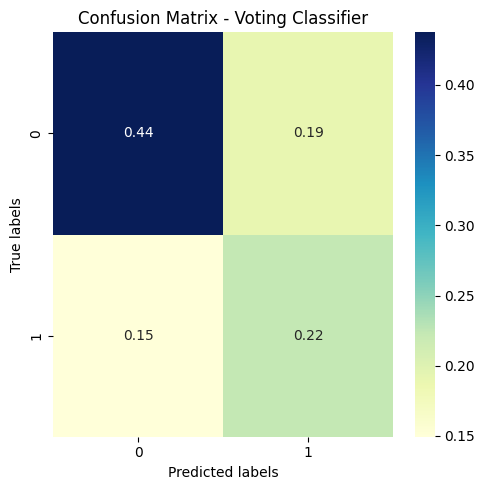

In [106]:
cm_vc = confusion_matrix(y_test, y_pred_voting)

plt.figure(figsize=(5, 5))  

#sns.heatmap(cm_vc, annot=True, cmap='YlGnBu', fmt='g')  
sns.heatmap(cm_vc/np.sum(cm_vc), annot = True, fmt=  '.2f', cmap = 'YlGnBu') 
plt.title('Confusion Matrix - Voting Classifier')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

plt.tight_layout()
plt.show()

## FINAL EVALUATION and BEST MODEL 

### ROC CURVE

The ROC (Receiver Operating Characteristic) curve is a graphical tool used to evaluate the performance of a classification model.
A ROC curve well positioned toward the upper left corner indicates a model with high discriminative performance, while a diagonal line represents a random model. The area under the ROC curve (AUC) provides a measure of the predictive ability of the model, where a value closer to 1 indicates better performance.

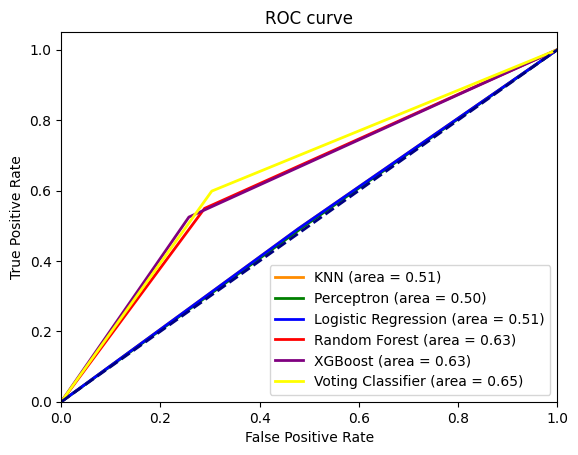

In [103]:
warnings.filterwarnings(action='ignore')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_best_logistic)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Perceptron
fpr_percep, tpr_percep, _ = roc_curve(y_test, y_best_perceptron)
roc_auc_percep = auc(fpr_percep, tpr_percep)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_best_logistic)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_best_randomforest)
roc_auc_rf = auc(fpr_rf, tpr_rf)

#XGB
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_best_XGB)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

#VotingClassifier
fpr_vc, tpr_vc, _ = roc_curve(y_test, y_pred_voting)
roc_auc_vc = auc(fpr_vc, tpr_vc)


plt.figure()
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label='KNN (area = %0.2f)' % roc_auc_knn)
plt.plot(fpr_percep, tpr_percep, color='green', lw=2, label='Perceptron (area = %0.2f)' % roc_auc_percep)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label='Logistic Regression (area = %0.2f)' % roc_auc_lr)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label='Random Forest (area = %0.2f)' % roc_auc_rf)
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label='XGBoost (area = %0.2f)' % roc_auc_xgb)
plt.plot(fpr_vc, tpr_vc, color='yellow', lw=2, label='Voting Classifier (area = %0.2f)' % roc_auc_vc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend(loc="lower right")
plt.show()

In [104]:
results_list = [results_knn, results_perceptron, results_lr, results_rf, results_xgb, results_voting]

tot_results = pd.concat(results_list)

tot_results_sorted = tot_results.sort_values(by='F1-Score', ascending=False)

print(tot_results_sorted)


                     Accuracy  Precision    Recall  F1-Score
VOTING CLASSIFIER    0.660061   0.668569  0.660061  0.663214
XGB                  0.661585   0.658870  0.661585  0.660074
RANDOM FOREST        0.650915   0.653623  0.650915  0.652148
KNN                  0.609756   0.633524  0.609756  0.615948
LOGISTIC REGRESSION  0.510671   0.539122  0.510671  0.518725
PERCEPTRON           0.504573   0.536973  0.504573  0.512834
